ВАРИАНТ 1 Распознование цифр 3,7

In [49]:
import numpy as np
from tensorflow.keras.datasets import mnist #импортируем датасет
import matplotlib.pyplot as plt
import time


In [50]:
print('Скачивание MNIST')
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print('Сохранение на диск')
allMnist = np.array([x_train, y_train, x_test, y_test], dtype=np.ndarray)
np.save('mnist',allMnist)

Скачивание MNIST
Сохранение на диск


In [51]:
#Загрузка с диска 
allMnist = np.load('mnist.npy', allow_pickle=True)

In [52]:
x_train, y_train, x_test, y_test = allMnist[0], allMnist[1],allMnist[2],allMnist[3]

In [53]:
print(x_train[y_train==3][0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  38  43 105 255 253 253 253
  253 253 174   6   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  43 139 224 226 252 253 252 252 252
  252 252 252 158  14   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 178 252 252 252 252 253 252 252 252
  252 252 252 252  59   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0 109 252 252 230 132 133 13

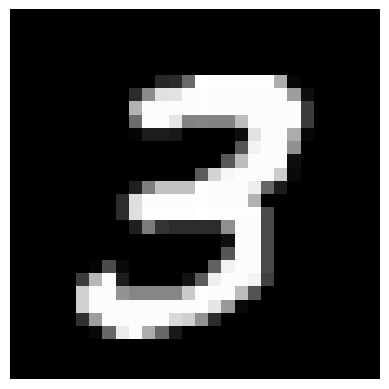

In [54]:
plt.axis('off')
plt.imshow(x_train[y_train==3][0], cmap='gray')
plt.show()

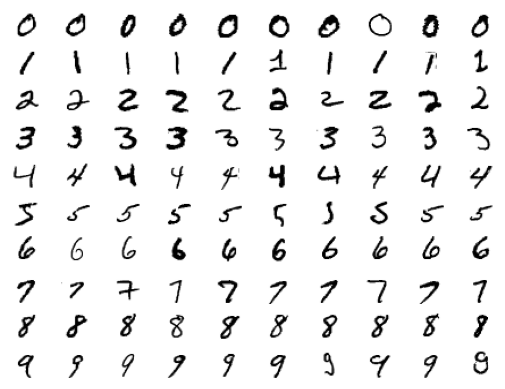

In [55]:
#Делаем выборку в двумерный массив по 10 образцов в каждой цифры
numbers = np.array([x_train[y_train==i][:10] for i in range(10)])
#подготовим окне 100 мест для рисунков
fig, axs = plt.subplots(nrows=10, ncols=10)

for i in range(10):
    for j in range(10):
        axs[i][j].axis('off')
        axs[i][j].imshow(numbers[i][j], cmap='binary')

plt.show()

распознавание образов заданных цифр 3 и 7 При помощи простейшего персептрона на 784+1 вход

In [56]:
def activation_function(wxb):
    #Функция активации персептрона.
    #wxb сумма произведений входных данных и весов, в которой
    #участвует также и смещение bias , стоящее на нулевой позиции вектора w
    if wxb >=0:
        return 1
    else:
        return 0

def predict(x,w):
    #Функция определяет класс поданного ей на вход образа X.
    #x вектор, содержащий входные данные конкретного образа.
    #w вектор, содержащий веса входов и смещение.
    # В процессе работы функция вычисляет скалярное произведение w и x
    #Полученное произведение передается в функцию активации, а
    #результат ее работы подается на выход данной функции.

    return activation_function(np.dot(x, w))

def forward_propagation(x, y, w):
    """
    Функция, определяющая качество распознавания конкретного образа.
    В процессе работы данная функция сначала обращается к функции predict и
    получает от нее цифровую метку предсказанного класса (y_pred)
    Далее функция вычисляет квадрат ошибки предсказания для образа « x » loss 
    а также значение производной от квадрата ошибки ( d_loss)
    :param x: вектор входных данных для конкретного образа.
    :param y: цифровая метка класса для правильного ответа (0 или 1).
    :param w: вектор, содержащий веса входов и смещение.
    :return: кортеж (y_pred, loss, d_loss).
    """
    # Получаем цифровую метку предсказанного класса
    y_pred = predict(x, w)
    # Вычисляем квадрат ошибки предсказания для образа «x»
    # Loss = (y_pred - y)^2
    loss = (y_pred - y) ** 2
    # Вычисляем значение производной от квадрата ошибки по предсказанию
    # d(Loss)/d(y_pred) = 2 * (y_pred - y)
    d_loss = 2 * (y_pred - y)
    return y_pred, loss, d_loss

def backpropagation(x, d_loss):
    """
    Функция вычисляет значение частных производных для каждого i-го входа.
    :param x: вектор входных данных.
    :param d_loss: значение производной от квадрата ошибки для образа «x».
    :return: произведение вектора «x» на скаляр d_loss (градиент).
    """
    # Возвращает вектор градиента   
    return x * d_loss

def optimize_perceptron(x_train, y_train, learning_rate, max_iterations=100):
    """
    Функция реализует алгоритм обучения персептрона.
    :param x_train: матрица образов обучающей выборки (каждая строка - образец с bias).
    :param y_train: вектор правильных цифровых меток классов.
    :param learning_rate: скорость обучения.
    :param max_iterations: максимальное количество итераций (эпох).
    :return: значения весов в основное тело программы.
    """
    n_features = x_train.shape[1]
    w = np.random.rand(n_features)
    count = 0
    aver_err = 1
    while count < max_iterations and aver_err > 0:
        
        for i in range(len(x_train)):
            x_i = x_train[i]
            y_i = y_train[i]

            _, _, dloss = forward_propagation(x_i, y_i, w)

            gradient = backpropagation(x_i, dloss)
            
            w = w - learning_rate*gradient
        loss_accumulator = 0
        for i in range(len(x_train)):
            x_i = x_train[i]
            y_i = y_train[i]

            _, loss, _ = forward_propagation(x_i, y_i, w)

            loss_accumulator += loss
        aver_err = loss_accumulator / len(x_train)
        count += 1
        print(f"Epoch {count}, Avg Loss: {aver_err}")
    return w

def optimize_perceptron_196(x_train, y_train, learning_rate, max_iterations=100):
    """
    Функция реализует алгоритм обучения персептрона.
    :param x_train: матрица образов обучающей выборки (каждая строка - образец с bias).
    :param y_train: вектор правильных цифровых меток классов.
    :param learning_rate: скорость обучения.
    :param max_iterations: максимальное количество итераций (эпох).
    :return: значения весов в основное тело программы.
    """
    n_features = x_train.shape[1]
    w = np.random.rand(n_features)
    count = 0
    aver_err = 1
    while count < max_iterations and aver_err > 0:
        
        for i in range(len(x_train)):
            x_i = x_train[i]
            y_i = y_train[i]

            _, _, dloss = forward_propagation(x_i, y_i, w)

            gradient = backpropagation(x_i, dloss)
            
            w = w - learning_rate*gradient
        loss_accumulator = 0
        for i in range(len(x_train)):
            x_i = x_train[i]
            y_i = y_train[i]

            _, loss, _ = forward_propagation(x_i, y_i, w)

            loss_accumulator += loss
        aver_err = loss_accumulator / len(x_train)
        count += 1
        print(f"Epoch {count}, Avg Loss: {aver_err}")
    return w
            



выборка подмножеств, относящихся только к интересующим нас цифрам 3 и 7

In [ ]:
x_train37 = x_train[np.logical_or(y_train==3, y_train==7)]
x_test37 = x_test[np.logical_or(y_test==3, y_test==7)]
y_train37 = y_train[np.logical_or(y_train==3, y_train==7)]
y_test37 = y_test[np.logical_or(y_test==3, y_test==7)]
# Персептрон на выходе выдает 0 или 1. 
# Однако в массивах y_train37 и y_test37 у вас остались оригинальные цифры 3 и 7.
# Заменяем 3 на 0, а 7 на 1
y_train37 = np.where(y_train37 == 3, 0, 1)
y_test37 = np.where(y_test37 == 3, 0, 1)
not_norm_x_train37 = x_train37
not_norm_x_test37 = x_test37

Изменение формы представления данных: с матрицы 28 x28 на вектор 1 x784

In [58]:
x_train37 = x_train37.reshape(x_train37.shape[0],28*28)
x_test37 = x_test37.reshape(x_test37.shape[0],28*28)


Нормализация данных, чтобы входы и выходы персептрона имели один масштаб

In [59]:
x_train37 = x_train37/np.max(x_train37)
x_test37 = x_test37/np.max(x_test37)

Добавление нулевого столбца с единичными значениями для учета
смещения строго после нормализации!!!

In [60]:
x_train37 = np.insert(x_train37, 0 , [1]*x_train37.shape[0], axis=1)
x_test37 = np.insert(x_test37, 0 , [1]*x_test37.shape[0], axis=1)

Запускаем процесс обучения и выводим в консоль получившиеся веса
Скорость обучения задаем константой рекомендуется начать с 0.01

In [61]:
print('Начинаем процесс обучения...')
start = time.time()
weights = optimize_perceptron(x_train37, y_train37, 0.1)
end = time.time() - start
print('Обучение закончено!')
print('Веса: ', weights)

Начинаем процесс обучения...
Epoch 1, Avg Loss: 0.026460148434979024
Epoch 2, Avg Loss: 0.023233301064859633
Epoch 3, Avg Loss: 0.016295579219102935
Epoch 4, Avg Loss: 0.021539206195546952
Epoch 5, Avg Loss: 0.01016456921587609
Epoch 6, Avg Loss: 0.012665375927718618
Epoch 7, Avg Loss: 0.012423362374959664
Epoch 8, Avg Loss: 0.009922555663117135
Epoch 9, Avg Loss: 0.011132623426911906
Epoch 10, Avg Loss: 0.012423362374959664
Epoch 11, Avg Loss: 0.01887705711519845
Epoch 12, Avg Loss: 0.010567925137141013
Epoch 13, Avg Loss: 0.011213294611164892
Epoch 14, Avg Loss: 0.012100677637947725
Epoch 15, Avg Loss: 0.011213294611164892
Epoch 16, Avg Loss: 0.009115843820587286
Epoch 17, Avg Loss: 0.016214908034849953
Epoch 18, Avg Loss: 0.008712487899322363
Epoch 19, Avg Loss: 0.020087124878993223
Epoch 20, Avg Loss: 0.013391416585995483
Epoch 21, Avg Loss: 0.007905776056792513
Epoch 22, Avg Loss: 0.010083898031623104
Epoch 23, Avg Loss: 0.014359470797031301
Epoch 24, Avg Loss: 0.00758309131978057


Теперь пройдем по тестовой выборке и определим индексы образов,
которые были распознаны неверно

In [62]:
count = 0
for i in range(x_test37.shape[0]):
    _, loss, _ = forward_propagation(x_test37[i], y_test37[i], weights)
    if loss != 0:
        print('Индекс нераспознанного примера : ', i)
        count +=1
print('Всего не распознаных чисел: ', count)

Индекс нераспознанного примера :  73
Индекс нераспознанного примера :  89
Индекс нераспознанного примера :  138
Индекс нераспознанного примера :  214
Индекс нераспознанного примера :  235
Индекс нераспознанного примера :  256
Индекс нераспознанного примера :  269
Индекс нераспознанного примера :  273
Индекс нераспознанного примера :  304
Индекс нераспознанного примера :  311
Индекс нераспознанного примера :  322
Индекс нераспознанного примера :  328
Индекс нераспознанного примера :  342
Индекс нераспознанного примера :  361
Индекс нераспознанного примера :  382
Индекс нераспознанного примера :  393
Индекс нераспознанного примера :  438
Индекс нераспознанного примера :  497
Индекс нераспознанного примера :  543
Индекс нераспознанного примера :  561
Индекс нераспознанного примера :  576
Индекс нераспознанного примера :  609
Индекс нераспознанного примера :  753
Индекс нераспознанного примера :  784
Индекс нераспознанного примера :  789
Индекс нераспознанного примера :  821
Индекс нераспо

Всего ошибок: 42 из 2038
Точность: 97.94%
Режим визуализации: 28x28


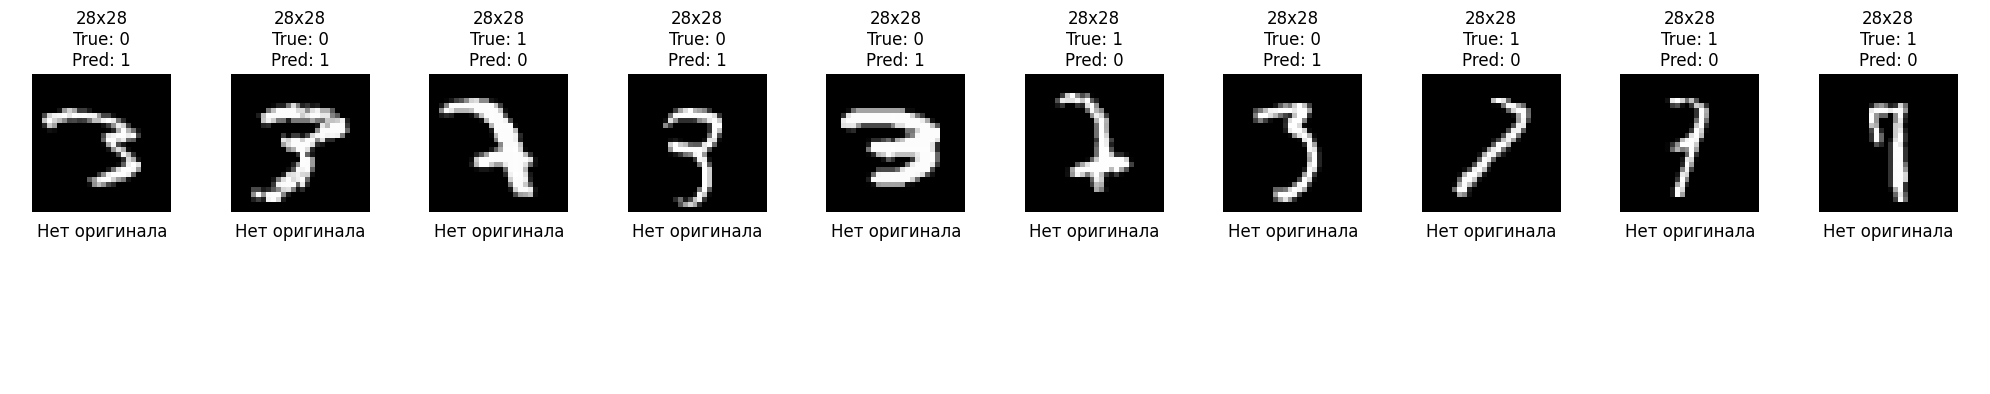

In [63]:
def visualize_weights(weights, title="Weights"):
    """
    Универсальная визуализация весов персептрона.
    """
    # Убираем bias
    if len(weights) == 785:  # 28x28 + bias
        weights_vis = weights[1:]
        img_size = 28
    elif len(weights) == 197:  # 14x14 + bias
        weights_vis = weights[1:]
        img_size = 14
    else:
        raise ValueError(f"Неподдерживаемое количество весов: {len(weights)}")
    
    # Нормализация по формуле из задания
    w_min = np.min(weights_vis)
    w_max = np.max(weights_vis)
    
    if w_max - w_min != 0:
        weights_normalized = 255 * (weights_vis - w_min) / (w_max - w_min)
    else:
        weights_normalized = np.zeros_like(weights_vis)
    
    weights_image = weights_normalized.reshape(img_size, img_size)
    
    # Отрисовка
    plt.figure(figsize=(6, 6))
    plt.imshow(weights_image, cmap='gray')
    plt.title(f"{title}\nРазмер: {img_size}x{img_size}, Весов: {len(weights_vis)}")
    plt.colorbar()
    plt.axis('off')
    plt.show()

def visualize_errors(x_test, y_test, weights, x_test_original=None, max_errors=10):
    """
    Универсальная функция для визуализации ошибочно распознанных цифр.
    Работает как для 28x28, так и для 14x14.
    
    :param x_test: Тестовая выборка (с bias).
    :param y_test: Истинные метки тестовой выборки.
    :param weights: Обученные веса персептрона.
    :param x_test_original: Оригинальные изображения (без bias, без нормализации) для детального просмотра.
    :param max_errors: Максимальное количество ошибок для отображения.
    """
    errors = []
    
    # 1. Поиск ошибок
    for i in range(x_test.shape[0]):
        y_pred, loss, _ = forward_propagation(x_test[i], y_test[i], weights)
        if loss != 0:
            errors.append({
                'index': i,
                'true_label': y_test[i],
                'predicted_label': y_pred,
                'image': x_test[i]
            })
    
    print(f'Всего ошибок: {len(errors)} из {len(y_test)}')
    print(f'Точность: {(len(y_test) - len(errors)) / len(y_test) * 100:.2f}%')
    
    if len(errors) == 0:
        print("Ошибок нет! Отличный результат!")
        return errors
    
    # 2. Определение размера изображения для визуализации
    n_features = len(weights) - 1  # Вычитаем bias
    if n_features == 784:
        img_size = 28
        print("Режим визуализации: 28x28")
    elif n_features == 196:
        img_size = 14
        print("Режим визуализации: 14x14")
    else:
        raise ValueError(f"Неподдерживаемый размер весов: {n_features}")
    
    # 3. Отрисовка
    n_errors = min(max_errors, len(errors))
    fig, axes = plt.subplots(2, n_errors, figsize=(2*n_errors, 4))
    if n_errors == 1:
        axes = axes.reshape(2, 1)  # Исправление для случая 1 ошибки
    
    for i, error in enumerate(errors[:n_errors]):
        idx = error['index']
        true_label = error['true_label']
        pred_label = error['predicted_label']
        image = error['image']
        
        # Убираем bias (первый элемент)
        image_vis = image[1:] if len(image) > n_features else image
        
        # Нормализация для отображения
        img_max = np.max(image_vis)
        image_vis = image_vis / img_max if img_max > 0 else image_vis
        image_reshaped = image_vis.reshape(img_size, img_size)
        
        # Верхний ряд: обработанное изображение
        axes[0, i].imshow(image_reshaped, cmap='gray')
        axes[0, i].set_title(f'{img_size}x{img_size}\nTrue: {true_label}\nPred: {pred_label}')
        axes[0, i].axis('off')
        
        # Нижний ряд: оригинал (если передан)
        if x_test_original is not None:
            orig_image = x_test_original[idx]
            axes[1, i].imshow(orig_image, cmap='gray')
            axes[1, i].set_title(f'Оригинал 28x28\nИндекс: {idx}')
            axes[1, i].axis('off')
        else:
            axes[1, i].axis('off')
            axes[1, i].set_title('Нет оригинала')
    
    plt.tight_layout()
    plt.show()
    
    return errors
# Запускаем анализ ошибок
errors = visualize_errors(x_test37, y_test37, weights, max_errors=10)



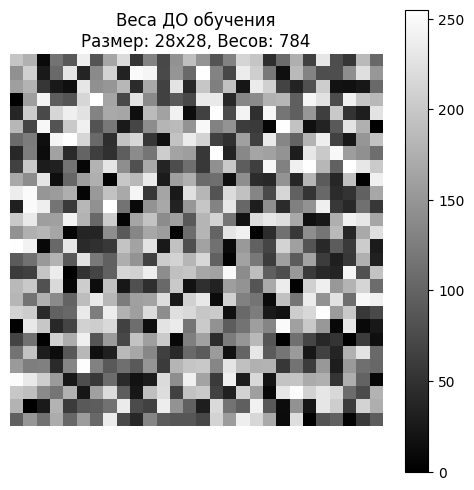

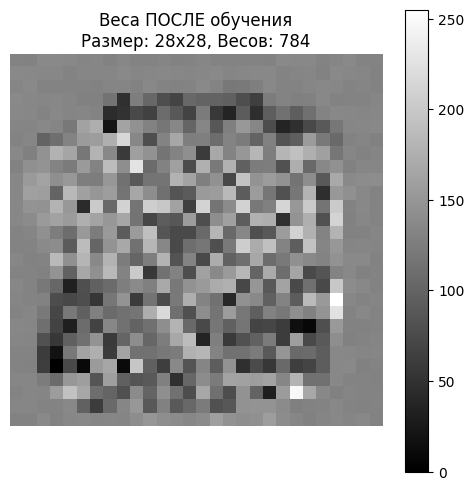

In [64]:
weights_before = np.random.rand(785)  # случайные веса
visualize_weights(weights_before, "Веса ДО обучения")

#  После обучения 
visualize_weights(weights, "Веса ПОСЛЕ обучения")

распознавание образов заданных цифр 3 и 7 При помощи простейшего персептрона уменьшенной размерности (на 196+1 вход).

In [65]:
def conv2d(images):
    n_samples = images.shape[0]
    
    # Преобразуем форму массива для группировки пикселей
    # Было: (n, 28, 28)
    # Стало: (n, 14, 2, 14, 2) -> где 2 и 2 это размеры блока для суммирования
    images_reshaped = images.reshape(n_samples, 14, 2, 14, 2)
    
    # Суммируем по осям 2 и 4 (внутренние двойки)
    # Это и есть операция суммирования квадратов 2x2
    images_downsampled = images_reshaped.sum(axis=(2, 4))

    return images_downsampled


x_test37_14_14 = conv2d(not_norm_x_test37)
x_train37_14_14 = conv2d(not_norm_x_train37)

Изменение формы представления данных: с матрицы 14x14 на вектор 1x196

In [66]:
x_train37_14_14 = x_train37_14_14.reshape(x_train37_14_14.shape[0],14*14)
x_test37_14_14 = x_test37_14_14.reshape(x_test37_14_14.shape[0],14*14)


Нормализация данных, чтобы входы и выходы персептрона имели один масштаб

In [67]:
x_train37_14_14 = x_train37_14_14/np.max(x_train37_14_14)
x_test37_14_14 = x_test37_14_14/np.max(x_test37_14_14)

Добавление нулевого столбца с единичными значениями для учета
смещения строго после нормализации!!!

In [68]:
x_train37_14_14 = np.insert(x_train37_14_14, 0 , [1]*x_train37_14_14.shape[0], axis=1)
x_test37_14_14 = np.insert(x_test37_14_14, 0 , [1]*x_test37_14_14.shape[0], axis=1)

In [69]:
print('Начинаем процесс обучения...')
start = time.time()
weights = optimize_perceptron_196(x_train37_14_14, y_train37, 0.1)
end = time.time() - start
print('Обучение закончено!')
print('Веса: ', weights)

Начинаем процесс обучения...
Epoch 1, Avg Loss: 0.018796385930945465
Epoch 2, Avg Loss: 0.036786060019361085
Epoch 3, Avg Loss: 0.01782833171990965
Epoch 4, Avg Loss: 0.013068731848983543
Epoch 5, Avg Loss: 0.00935785737334624
Epoch 6, Avg Loss: 0.01903839948370442
Epoch 7, Avg Loss: 0.028960955146821555
Epoch 8, Avg Loss: 0.02516940948693127
Epoch 9, Avg Loss: 0.018635043562439498
Epoch 10, Avg Loss: 0.025411423039690222
Epoch 11, Avg Loss: 0.011132623426911906
Epoch 12, Avg Loss: 0.022103904485317846
Epoch 13, Avg Loss: 0.010648596321393998
Epoch 14, Avg Loss: 0.010245240400129073
Epoch 15, Avg Loss: 0.011455308163923846
Epoch 16, Avg Loss: 0.012342691190706679
Epoch 17, Avg Loss: 0.02016779606324621
Epoch 18, Avg Loss: 0.013714101323007422
Epoch 19, Avg Loss: 0.013149403033236529
Epoch 20, Avg Loss: 0.009438528557599225
Epoch 21, Avg Loss: 0.02291061632784769
Epoch 22, Avg Loss: 0.010406582768635044
Epoch 23, Avg Loss: 0.011213294611164892
Epoch 24, Avg Loss: 0.026298806066473057
Ep

Всего ошибок: 34 из 2038
Точность: 98.33%
Режим визуализации: 14x14


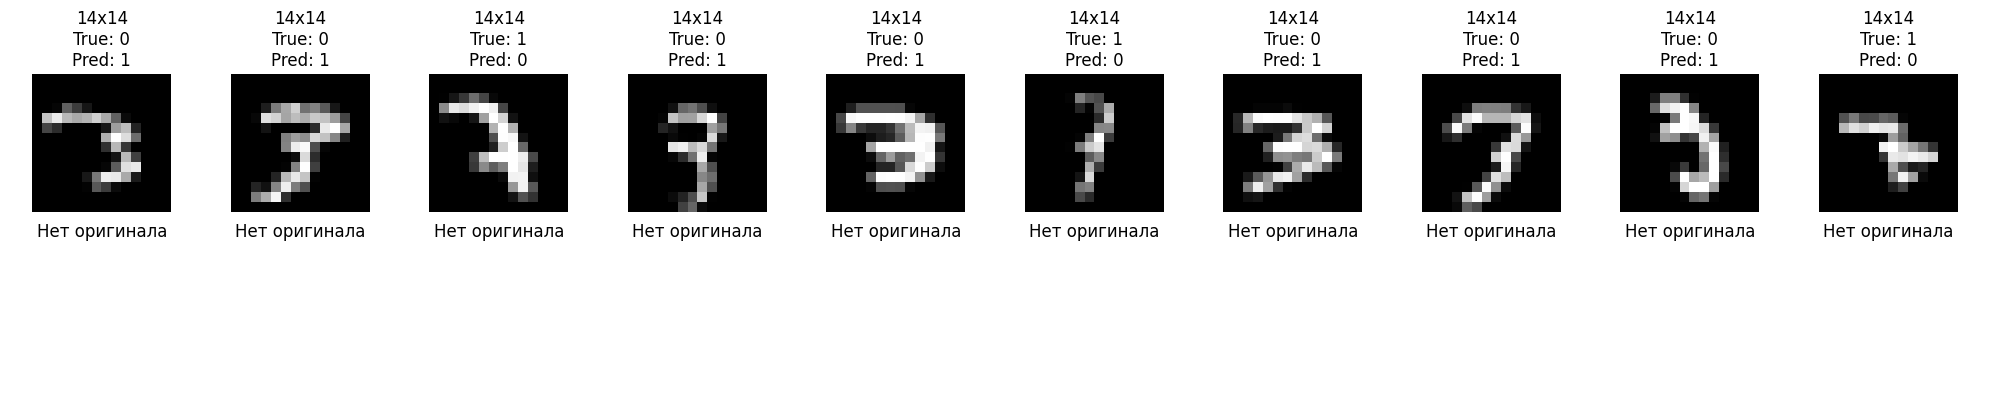

In [70]:
# Запускаем анализ ошибок
errors = visualize_errors(x_test37_14_14, y_test37, weights, max_errors=10)

In [71]:
count = 0
for i in range(x_test37_14_14.shape[0]):
    _, loss, _ = forward_propagation(x_test37_14_14[i], y_test37[i], weights)
    if loss != 0:
        print('Индекс нераспознанного примера : ', i)
        count +=1
print('Всего не распознаных чисел: ', count)

Индекс нераспознанного примера :  73
Индекс нераспознанного примера :  89
Индекс нераспознанного примера :  138
Индекс нераспознанного примера :  214
Индекс нераспознанного примера :  235
Индекс нераспознанного примера :  304
Индекс нераспознанного примера :  328
Индекс нераспознанного примера :  342
Индекс нераспознанного примера :  382
Индекс нераспознанного примера :  393
Индекс нераспознанного примера :  438
Индекс нераспознанного примера :  501
Индекс нераспознанного примера :  543
Индекс нераспознанного примера :  561
Индекс нераспознанного примера :  576
Индекс нераспознанного примера :  609
Индекс нераспознанного примера :  678
Индекс нераспознанного примера :  683
Индекс нераспознанного примера :  725
Индекс нераспознанного примера :  784
Индекс нераспознанного примера :  789
Индекс нераспознанного примера :  871
Индекс нераспознанного примера :  887
Индекс нераспознанного примера :  888
Индекс нераспознанного примера :  917
Индекс нераспознанного примера :  1003
Индекс нерасп

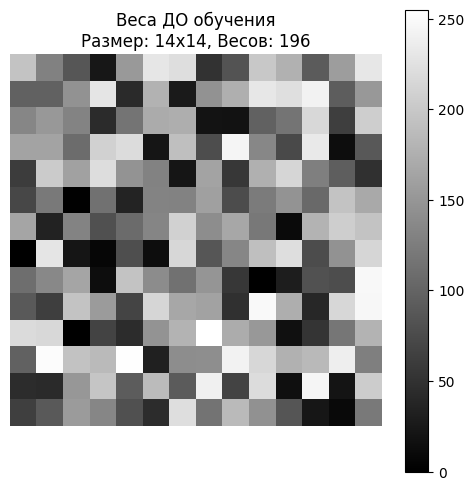

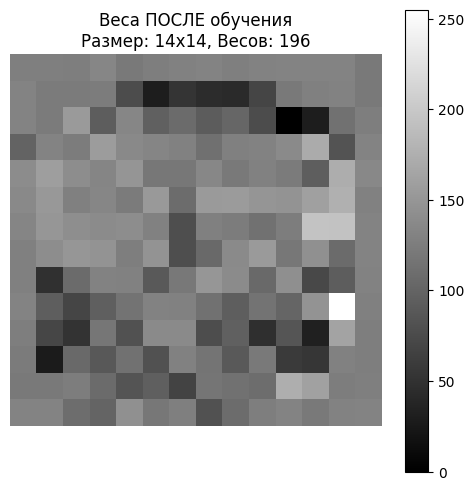

In [72]:
weights_before = np.random.rand(197)  # случайные веса
visualize_weights(weights_before, "Веса ДО обучения")

# После обучения 
visualize_weights(weights, "Веса ПОСЛЕ обучения")